# Notebook 01 - Data Understanding

**Project:** Diabetes Readmission Risk Prediction  
**Dataset:** Diabetes 130-US Hospitals for Years 1999-2008  
**Source:** UCI Machine Learning Repository  
**Author:** Umanda Thathsarani | IT3091 Machine Learning  

---

## What I want to figure out in this notebook

Before I touch any modelling, I need to actually understand what I'm working with. I downloaded the dataset from the UCI repository and this notebook is basically my first proper look at it.

The main questions I want to answer here:

1. What does one row actually represent? (Is it a patient? A hospital visit? Something else?)
2. How many rows and columns are there?
3. What are all the columns and what do they mean?
4. What does the target variable (`readmitted`) look like?
5. Are there missing values? How are they encoded?
6. Any duplicate records?
7. If the same patient appears multiple times, how does that affect my analysis?

I'll keep all statistics honest - nothing is made up here. Everything comes from actually running the code.

---

**A quick note on the data:** This dataset contains de-identified clinical records from 130 US hospitals. I'll be careful not to print large amounts of raw patient-level data and I'll treat it responsibly throughout.


---
## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
RAW_DATA_DIR = Path('../data/raw')
FIGURES_DIR  = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FIGURE_DPI = 150

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

print('Libraries loaded successfully.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')


Libraries loaded successfully.
pandas  : 3.0.3
numpy   : 2.4.6


---
## 2. Loading the Dataset


In [2]:
# Load main encounter data
DATA_FILE = RAW_DATA_DIR / 'diabetic_data.csv'
IDS_FILE  = RAW_DATA_DIR / 'IDS_mapping.csv'

assert DATA_FILE.exists(), f'Dataset not found: {DATA_FILE}\nSee README.md > Reproducibility for download instructions.'
assert IDS_FILE.exists(),  f'IDs mapping not found: {IDS_FILE}'

df  = pd.read_csv(DATA_FILE)
ids = pd.read_csv(IDS_FILE)

print(f'Main data loaded:  {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'IDs mapping loaded: {ids.shape[0]} rows × {ids.shape[1]} columns')


Main data loaded:  101,766 rows × 50 columns
IDs mapping loaded: 67 rows × 2 columns


---
## 3. What Does One Row Actually Represent?

This is probably the most important question to answer before doing anything else. Is each row a unique patient, or can one patient appear multiple times? This completely changes how I should think about the data and especially how I should split it for training and testing.


In [3]:
total_rows      = len(df)
unique_encounter= df['encounter_id'].nunique()
unique_patient  = df['patient_nbr'].nunique()
multi_encounter = (df['patient_nbr'].value_counts() > 1).sum()
max_enc_per_pat = df['patient_nbr'].value_counts().max()

print('=== Unit of Analysis ===')
print(f'Total rows              : {total_rows:,}')
print(f'Unique encounter_id     : {unique_encounter:,}')
print(f'Unique patient_nbr      : {unique_patient:,}')
print(f'Patients with >1 encounter: {multi_encounter:,} ({100*multi_encounter/unique_patient:.1f}% of patients)')
print(f'Max encounters per patient: {max_enc_per_pat}')
print()
print('FINDING: encounter_id is unique per row.')
print('         patient_nbr is NOT unique - one patient may have multiple encounters.')
print('         => Each ROW represents a PATIENT ENCOUNTER (hospital visit), not a unique patient.')


=== Unit of Analysis ===
Total rows              : 101,766
Unique encounter_id     : 101,766
Unique patient_nbr      : 71,518
Patients with >1 encounter: 16,773 (23.5% of patients)
Max encounters per patient: 40

FINDING: encounter_id is unique per row.
         patient_nbr is NOT unique — one patient may have multiple encounters.
         => Each ROW represents a PATIENT ENCOUNTER (hospital visit), not a unique patient.


> **Key Finding - Unit of Analysis:**  
> Each row is a **patient encounter (one hospital admission)**, not a unique patient. The same patient can show up multiple times in the data - once for each time they were hospitalized.
>
> This matters a lot because:
> - If I do a random train/test split, the same patient's encounters could end up in both the training set and the test set. That would be a form of data leakage.
> - The model predicts encounter-level risk, not a person's long-term readmission risk.
> - I can potentially engineer features based on each patient's history of prior encounters.
>
> I'll document this in the decision log and make sure my splitting strategy accounts for it.


---
## 4. Dataset Shape and Column Overview


In [4]:
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Column names and types:')
print('-' * 50)
for col in df.columns:
    print(f'  {col:<35} {str(df[col].dtype)}')


Shape: 101,766 rows × 50 columns

Column names and types:
--------------------------------------------------
  encounter_id                        int64
  patient_nbr                         int64
  race                                str
  gender                              str
  age                                 str
  weight                              str
  admission_type_id                   int64
  discharge_disposition_id            int64
  admission_source_id                 int64
  time_in_hospital                    int64
  payer_code                          str
  medical_specialty                   str
  num_lab_procedures                  int64
  num_procedures                      int64
  num_medications                     int64
  number_outpatient                   int64
  number_emergency                    int64
  number_inpatient                    int64
  diag_1                              str
  diag_2                              str
  diag_3                   

In [5]:
# Show first 3 rows (anonymised view - no raw sensitive print)
# We show column headers and a few rows to understand the structure.
# Actual patient identifiers (encounter_id, patient_nbr) are integers;
# no names, dates of birth, or direct identifiers are present.
print('First 3 rows (structure preview only):')
df.head(3)


First 3 rows (structure preview only):


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


---
## 5. Classifying All Columns by Their Role

Before I can build anything useful, I need to know what each column actually is. I've gone through all 50 columns and grouped them into categories based on what they represent.


In [6]:
# --- Column role classification ---
IDENTIFIERS = ['encounter_id', 'patient_nbr']

DEMOGRAPHICS = ['race', 'gender', 'age']

ADMISSION_INFO = [
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'payer_code', 'medical_specialty'
]

CLINICAL_NUMERIC = [
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses'
]

DIAGNOSIS = ['diag_1', 'diag_2', 'diag_3']

LAB_RESULTS = ['max_glu_serum', 'A1Cresult', 'weight']

MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

MEDICATION_SUMMARY = ['change', 'diabetesMed']

TARGET = ['readmitted']

# Verify we've accounted for all columns
all_classified = (IDENTIFIERS + DEMOGRAPHICS + ADMISSION_INFO +
                  CLINICAL_NUMERIC + DIAGNOSIS + LAB_RESULTS +
                  MEDICATION_COLS + MEDICATION_SUMMARY + TARGET)
missing = [c for c in df.columns if c not in all_classified]
extra   = [c for c in all_classified if c not in df.columns]

print(f'Identifiers      : {len(IDENTIFIERS)}')
print(f'Demographics     : {len(DEMOGRAPHICS)}')
print(f'Admission info   : {len(ADMISSION_INFO)}')
print(f'Clinical numeric : {len(CLINICAL_NUMERIC)}')
print(f'Diagnosis        : {len(DIAGNOSIS)}')
print(f'Lab results      : {len(LAB_RESULTS)}')
print(f'Medication cols  : {len(MEDICATION_COLS)}')
print(f'Med summary      : {len(MEDICATION_SUMMARY)}')
print(f'Target           : {len(TARGET)}')
print(f'Total accounted  : {len(all_classified)}')
print(f'Total in dataset : {df.shape[1]}')
print()
if missing: print(f'WARNING - unclassified columns: {missing}')
if extra:   print(f'WARNING - columns in list but not in dataset: {extra}')
if not missing and not extra: print('All 50 columns classified correctly.')


Identifiers      : 2
Demographics     : 3
Admission info   : 6
Clinical numeric : 7
Diagnosis        : 3
Lab results      : 3
Medication cols  : 23
Med summary      : 2
Target           : 1
Total accounted  : 50
Total in dataset : 50

All 50 columns classified correctly.


---
## 6. The Target Variable - `readmitted`

This is what I'm trying to predict. Let me look at the distribution carefully before making any decisions about how to formulate the prediction task.


In [7]:
target_counts = df['readmitted'].value_counts()
target_pct    = df['readmitted'].value_counts(normalize=True).round(4) * 100

print('Target: readmitted')
print('=' * 40)
print(f'{"Category":<10} {"Count":>10} {"Percent":>10}')
print('-' * 40)
for cat in ['NO', '>30', '<30']:
    print(f'{cat:<10} {target_counts[cat]:>10,} {target_pct[cat]:>9.1f}%')
print('-' * 40)
print(f'{"TOTAL":<10} {target_counts.sum():>10,} {100.0:>9.1f}%')
print()
print('Category meanings:')
print('  NO   = Patient was NOT readmitted')
print('  >30  = Patient was readmitted AFTER 30 days')
print('  <30  = Patient was readmitted WITHIN 30 days (highest clinical concern)')


Target: readmitted
Category        Count    Percent
----------------------------------------
NO             54,864      53.9%
>30            35,545      34.9%
<30            11,357      11.2%
----------------------------------------
TOTAL         101,766     100.0%

Category meanings:
  NO   = Patient was NOT readmitted
  >30  = Patient was readmitted AFTER 30 days
  <30  = Patient was readmitted WITHIN 30 days (highest clinical concern)


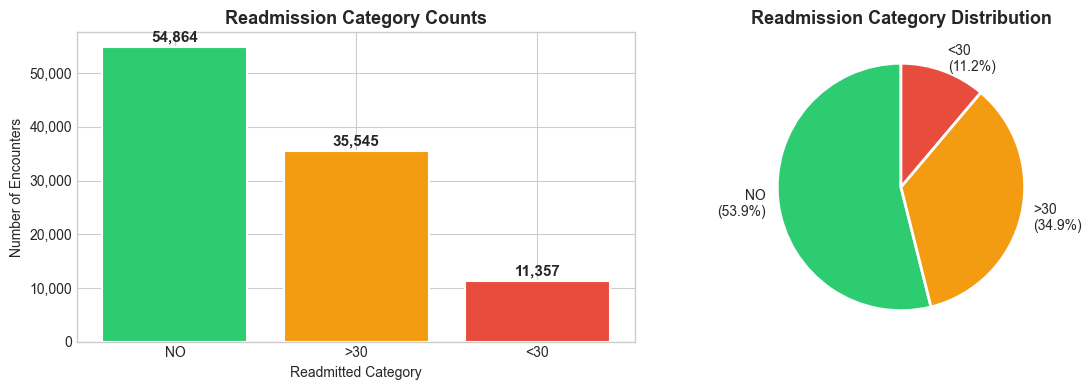

Figure saved: reports/figures/01_target_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
cats   = ['NO', '>30', '<30']
counts = [target_counts[c] for c in cats]

bars = axes[0].bar(cats, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Readmission Category Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmitted Category')
axes[0].set_ylabel('Number of Encounters')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
pcts = [target_pct[c] for c in cats]
axes[1].pie(pcts, labels=[f'{c}\n({p:.1f}%)' for c, p in zip(cats, pcts)],
            colors=colors, autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Readmission Category Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/01_target_distribution.png')


> **What I see here:**
> - Most encounters (about 54%) result in no readmission at all
> - About 35% of patients are readmitted but after 30 days
> - Only about 11% are readmitted within 30 days - which is the outcome hospitals care most about
>
> The `<30` class is clearly the minority. This is going to be a challenge for modelling because a model could just predict "never readmitted" and be right 89% of the time. I'll need to use metrics beyond accuracy and probably handle the class imbalance somehow.
>
> I'll document my target definition decision in `reports/decision_log.md`.


---
## 7. Missing Values

One thing I noticed when loading the data - it uses `?` as the placeholder for missing values, not Python's `NaN`. That's unusual and means I need to handle this explicitly. Let me find all columns that have `?` entries.


In [9]:
# Count '?' placeholders (used in this dataset for missing values)
question_mark_counts = {col: (df[col] == '?').sum() for col in df.columns}
nan_counts           = df.isnull().sum()

missing_summary = pd.DataFrame({
    'question_mark': pd.Series(question_mark_counts),
    'true_nan': nan_counts
})
missing_summary['total_missing'] = missing_summary['question_mark'] + missing_summary['true_nan']
missing_summary['pct_missing'] = (missing_summary['total_missing'] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary['total_missing'] > 0].sort_values('total_missing', ascending=False)

print(f'Columns with any missing (? or NaN): {len(missing_summary)}')
print()
print(missing_summary.to_string())


Columns with any missing (? or NaN): 9

                   question_mark  true_nan  total_missing  pct_missing
weight                     98569         0          98569        96.86
max_glu_serum                  0     96420          96420        94.75
A1Cresult                      0     84748          84748        83.28
medical_specialty          49949         0          49949        49.08
payer_code                 40256         0          40256        39.56
race                        2273         0           2273         2.23
diag_3                      1423         0           1423         1.40
diag_2                       358         0            358         0.35
diag_1                        21         0             21         0.02


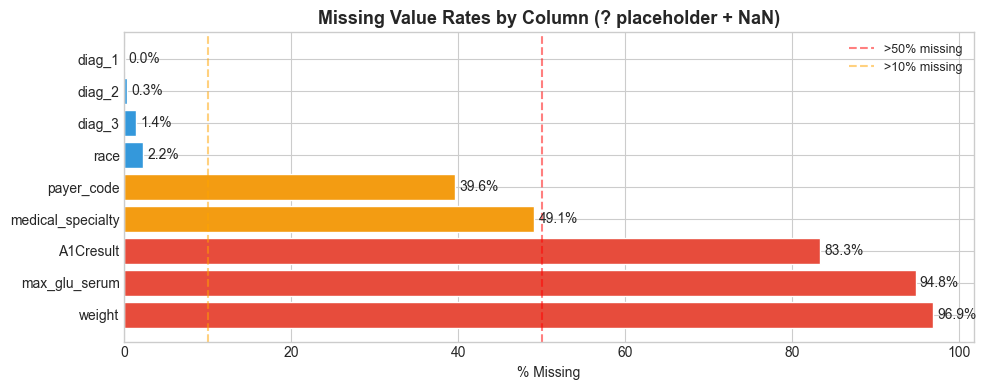

Figure saved: reports/figures/01_missing_values.png


In [10]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 4))

cols = missing_summary.index.tolist()
pcts = missing_summary['pct_missing'].tolist()
colors_miss = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db' for p in pcts]

bars = ax.barh(cols, pcts, color=colors_miss, edgecolor='white')
for bar, p in zip(bars, pcts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{p:.1f}%', va='center', fontsize=10)

ax.set_xlabel('% Missing')
ax.set_title('Missing Value Rates by Column (? placeholder + NaN)', fontsize=13, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='>50% missing')
ax.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='>10% missing')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_missing_values.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/01_missing_values.png')


> **What jumped out at me here:**
>
> | Column | % Missing | What I'll do |
> |--------|-----------|-------------|
> | `weight` | ~96.9% | Drop - way too sparse to be useful |
> | `medical_specialty` | ~49.1% | High missingness - treat as 'Unknown' category |
> | `payer_code` | ~39.6% | High missingness - need to decide whether to keep |
> | `race` | ~2.2% | Low - can treat missing as its own category |
> | `diag_1/2/3` | Very low | Manageable |
>
> The `weight` column is basically unusable with 96.9% missing. I'll just drop it.


---
## 8. Numeric Variable Summary


In [11]:
numeric_cols = CLINICAL_NUMERIC + ['time_in_hospital',
                                    'admission_type_id',
                                    'discharge_disposition_id',
                                    'admission_source_id']
print('Numeric variable summary:')
df[numeric_cols].describe().T.round(2)


Numeric variable summary:


,count,mean,std,min,25%,50%,75%,max
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
admission_type_id,101766.0,2.02,1.45,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.72,5.28,1.0,1.0,1.0,4.0,28.0


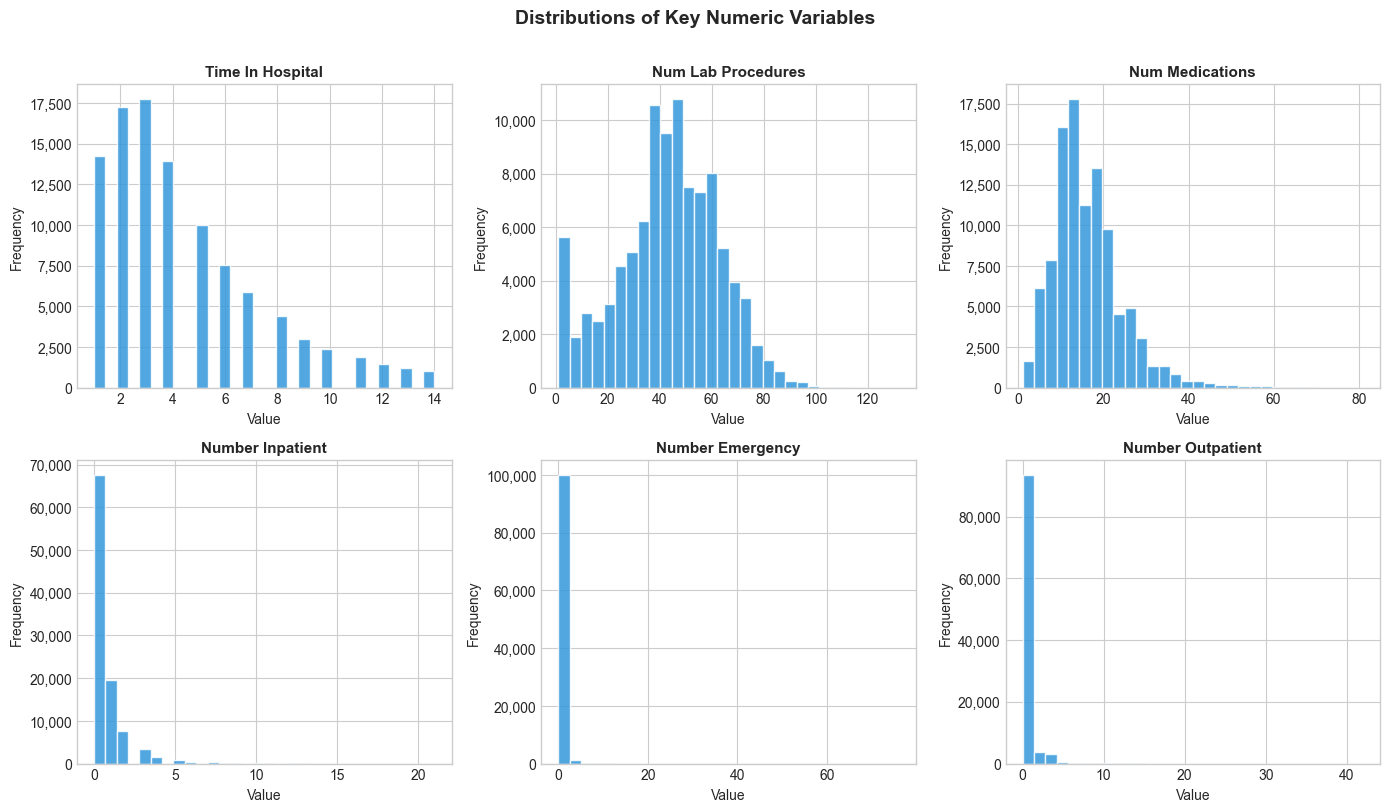

Figure saved: reports/figures/01_numeric_distributions.png


In [12]:
# Distributions of key numeric variables
plot_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
             'number_inpatient', 'number_emergency', 'number_outpatient']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distributions of Key Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_numeric_distributions.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/01_numeric_distributions.png')


---
## 9. Categorical Variable Overview


In [13]:
print('Unique value counts for key categorical variables:')
cat_cols = DEMOGRAPHICS + ['payer_code', 'medical_specialty',
                             'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']
for col in cat_cols:
    n_unique = df[col].nunique()
    top_vals = df[col].value_counts().head(5).to_dict()
    print(f'\n  {col} ({n_unique} unique):')
    for val, cnt in top_vals.items():
        print(f'    {str(val):<30} {cnt:>8,} ({100*cnt/len(df):.1f}%)')


Unique value counts for key categorical variables:

  race (6 unique):
    Caucasian                        76,099 (74.8%)
    AfricanAmerican                  19,210 (18.9%)
    ?                                 2,273 (2.2%)
    Hispanic                          2,037 (2.0%)
    Other                             1,506 (1.5%)

  gender (3 unique):
    Female                           54,708 (53.8%)
    Male                             47,055 (46.2%)
    Unknown/Invalid                       3 (0.0%)

  age (10 unique):
    [70-80)                          26,068 (25.6%)
    [60-70)                          22,483 (22.1%)
    [50-60)                          17,256 (17.0%)
    [80-90)                          17,197 (16.9%)
    [40-50)                           9,685 (9.5%)

  payer_code (18 unique):
    ?                                40,256 (39.6%)
    MC                               32,439 (31.9%)
    HM                                6,274 (6.2%)
    SP                            

In [14]:
# Medication columns - check unique values (should be: No Change, Down, Steady, Up)
print('Medication column unique values:')
for col in MEDICATION_COLS[:5]:  # Sample first 5
    vals = df[col].value_counts().to_dict()
    print(f'  {col}: {vals}')
print('  ...')
print(f'  (All {len(MEDICATION_COLS)} medication columns follow the same structure)')


Medication column unique values:
  metformin: {'No': 81778, 'Steady': 18346, 'Up': 1067, 'Down': 575}
  repaglinide: {'No': 100227, 'Steady': 1384, 'Up': 110, 'Down': 45}
  nateglinide: {'No': 101063, 'Steady': 668, 'Up': 24, 'Down': 11}
  chlorpropamide: {'No': 101680, 'Steady': 79, 'Up': 6, 'Down': 1}
  glimepiride: {'No': 96575, 'Steady': 4670, 'Up': 327, 'Down': 194}
  ...
  (All 23 medication columns follow the same structure)


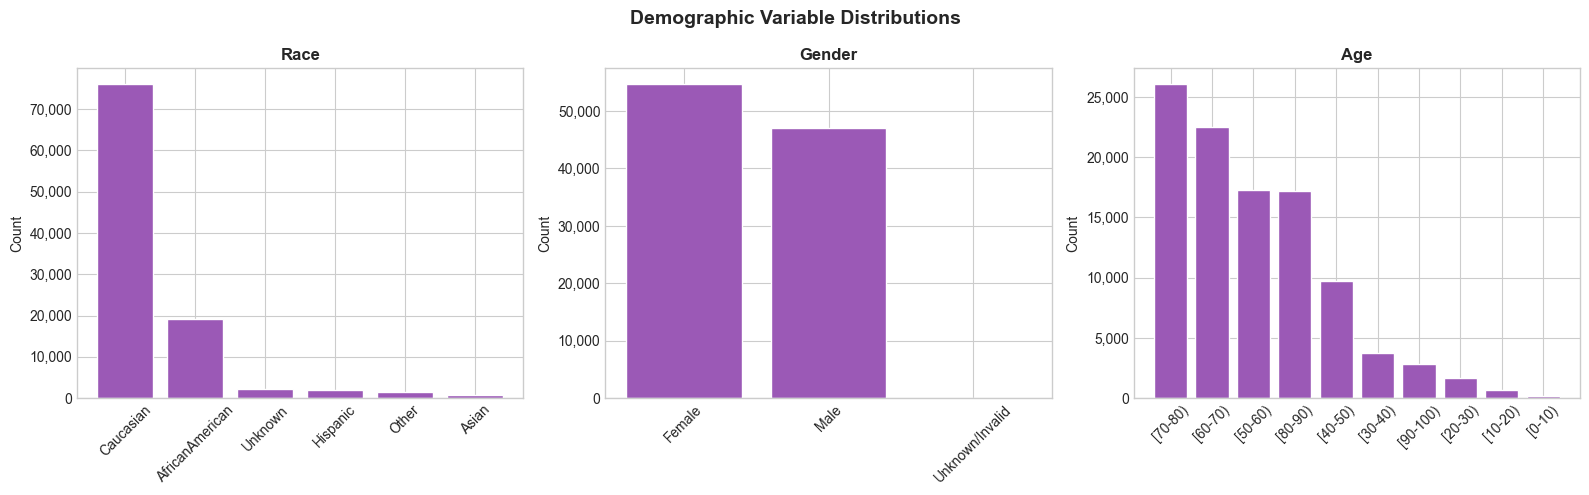

Figure saved: reports/figures/01_demographics.png


In [15]:
# Demographics visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, DEMOGRAPHICS):
    vc = df[col].replace('?', 'Unknown').value_counts()
    ax.bar(vc.index, vc.values, color='#9b59b6', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Demographic Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_demographics.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/01_demographics.png')


---
## 10. IDs Mapping - Understanding the Coded Values

Several columns use integer codes that map to descriptions. The `IDS_mapping.csv` file that came with the dataset explains what these codes mean. Let me look at it.


In [16]:
print('IDS_mapping.csv contents:')
print(ids.to_string())


IDS_mapping.csv contents:
           admission_type_id                                                                                                description
0                          1                                                                                                  Emergency
1                          2                                                                                                     Urgent
2                          3                                                                                                   Elective
3                          4                                                                                                    Newborn
4                          5                                                                                              Not Available
5                          6                                                                                                        NaN
6                     

---
## 11. A Potential Problem - Discharge Disposition and Leakage

Looking at `discharge_disposition_id`, I noticed some codes that immediately flagged as a problem. Codes like 11 (Expired) and 13/14 (Hospice) indicate the patient *died* during or shortly after their stay. For those patients, readmission is literally impossible.

Including those rows in the model would mean the negative class ('not readmitted') includes both patients who recovered fine AND patients who passed away. That's not quite right - it's a different kind of 'no readmission'. I should probably remove or at least flag these.


In [17]:
# Counts by discharge_disposition_id and readmission
print('Discharge disposition top categories:')
print(df['discharge_disposition_id'].value_counts().head(15).to_string())
print()

# Identify problematic dispositions
# From IDS_mapping: 11=Expired, 13=Hospice/home, 14=Hospice/medical facility,
#                   19=Expired at home (hospice), 20=Expired in medical facility (hospice)
problematic_ids = [11, 13, 14, 19, 20, 21]
problematic_rows = df[df['discharge_disposition_id'].isin(problematic_ids)]
print(f'Encounters with death/hospice discharge codes: {len(problematic_rows):,}')
print(f'Their readmission distribution:')
print(problematic_rows['readmitted'].value_counts())
print()
print('NOTE: These records should likely be EXCLUDED - readmission is not applicable.')
print('This will be documented in decision_log.md DEC-004 (Leakage Analysis).')


Discharge disposition top categories:
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139

Encounters with death/hospice discharge codes: 2,423
Their readmission distribution:
readmitted
NO     2337
<30      43
>30      43
Name: count, dtype: int64

NOTE: These records should likely be EXCLUDED — readmission is not applicable.
This will be documented in decision_log.md DEC-004 (Leakage Analysis).


---
## 12. Checking for Duplicate Records


In [18]:
# Are there fully duplicate rows?
n_fully_duplicate = df.duplicated().sum()
n_enc_duplicate   = df['encounter_id'].duplicated().sum()

print(f'Fully duplicate rows         : {n_fully_duplicate:,}')
print(f'Duplicate encounter_id values: {n_enc_duplicate:,}')
print()
if n_fully_duplicate == 0 and n_enc_duplicate == 0:
    print('No duplicate rows or encounter IDs found.')
    print('Each encounter_id is unique => each row is a distinct hospital visit.')


Fully duplicate rows         : 0
Duplicate encounter_id values: 0

No duplicate rows or encounter IDs found.
Each encounter_id is unique => each row is a distinct hospital visit.


---
## 13. How Often Does the Same Patient Appear?

I already confirmed that patients can appear multiple times. Now I want to understand *how* often - is it rare, or do many patients have several encounters in the dataset?


In [19]:
encounter_counts_per_patient = df['patient_nbr'].value_counts()
enc_dist = encounter_counts_per_patient.value_counts().sort_index()

print('Distribution of encounters per patient:')
print(f'{"Encounters":<15} {"# Patients":>12} {"% of Patients":>15}')
print('-' * 45)
for n_enc, n_pat in enc_dist.head(10).items():
    pct = 100 * n_pat / unique_patient
    print(f'{n_enc:<15} {n_pat:>12,} {pct:>14.1f}%')
if len(enc_dist) > 10:
    print('...')

print()
print(f'Patients with exactly 1 encounter : {enc_dist.get(1, 0):,} ({100*enc_dist.get(1,0)/unique_patient:.1f}%)')
print(f'Patients with 2+ encounters       : {multi_encounter:,} ({100*multi_encounter/unique_patient:.1f}%)')
print(f'Maximum encounters for one patient: {encounter_counts_per_patient.max()}')
print()
print('IMPLICATION: A naive random train/test split could place encounters')
print('from the same patient in both training and test sets.')
print('This will be addressed in the data splitting strategy (DEC-005).')


Distribution of encounters per patient:
Encounters        # Patients   % of Patients
---------------------------------------------
1                     54,745           76.5%
2                     10,434           14.6%
3                      3,328            4.7%
4                      1,421            2.0%
5                        717            1.0%
6                        346            0.5%
7                        207            0.3%
8                        111            0.2%
9                         70            0.1%
10                        42            0.1%
...

Patients with exactly 1 encounter : 54,745 (76.5%)
Patients with 2+ encounters       : 16,773 (23.5%)
Maximum encounters for one patient: 40

IMPLICATION: A naive random train/test split could place encounters
from the same patient in both training and test sets.
This will be addressed in the data splitting strategy (DEC-005).


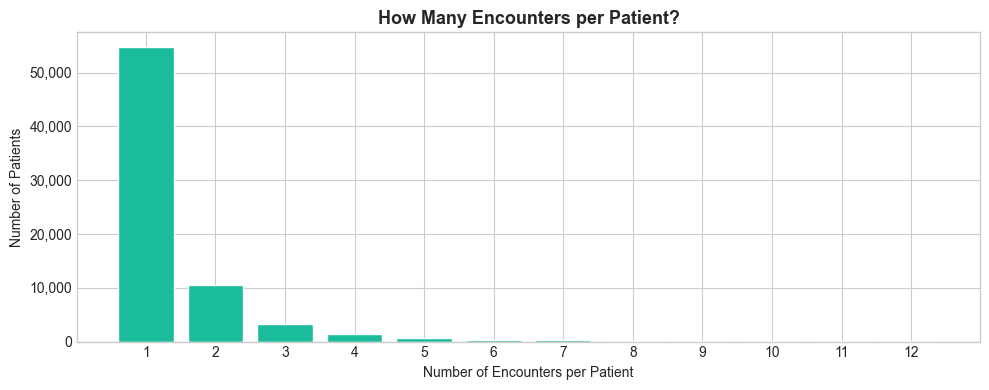

Figure saved: reports/figures/01_encounters_per_patient.png


In [20]:
# Visualise encounter frequency distribution
fig, ax = plt.subplots(figsize=(10, 4))
enc_dist_plot = enc_dist[enc_dist.index <= 12]  # Cap at 12 for readability
ax.bar(enc_dist_plot.index, enc_dist_plot.values, color='#1abc9c', edgecolor='white')
ax.set_xlabel('Number of Encounters per Patient')
ax.set_ylabel('Number of Patients')
ax.set_title('How Many Encounters per Patient?', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(1, enc_dist_plot.index.max() + 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_encounters_per_patient.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print('Figure saved: reports/figures/01_encounters_per_patient.png')


---
## 14. Summary - What I Found

### Key Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Each row is a **patient encounter**, not a unique patient | `encounter_id` is unique (101,766) but `patient_nbr` has only 71,518 unique values |
| 2 | **23.5%** of patients appear more than once | 16,773 patients have 2 or more encounters |
| 3 | Target `readmitted` has 3 classes: NO (53.9%), >30 (34.9%), <30 (11.2%) | `value_counts()` on readmitted column |
| 4 | The `<30` class is heavily outnumbered (~11%) | Class imbalance needs to be handled |
| 5 | `weight` has **96.9% missing** values | Missing value scan |
| 6 | `medical_specialty` (49.1%) and `payer_code` (39.6%) have high missingness | Missing value scan |
| 7 | Missing values are stored as **`?` strings**, not NaN | Dataset inspection |
| 8 | Discharge codes 11/13/14/19/20 = death or hospice - readmission not applicable | IDS_mapping.csv |
| 9 | **No fully duplicate rows** or duplicate encounter IDs | `duplicated()` check |
| 10 | Dataset has **50 columns** across identifiers, demographics, clinical, medications, and target | Column classification |

### Decisions Made

| Decision | Where it's documented |
|----------|----------------------|
| Unit of analysis = encounter level (not patient level) | `decision_log.md DEC-002` |
| Patient-aware splitting is needed | `decision_log.md DEC-005` |
| `weight` will be dropped (96.9% missing) | `preprocessing_feature_log.md` |
| Discharge codes 11/13/14/19/20 flagged for removal | `decision_log.md DEC-004` |
| Target binary formulation to be confirmed after EDA | `decision_log.md DEC-003` |
| `?` placeholders must be converted to NaN in preprocessing | `preprocessing_feature_log.md` |

---

Next up is Notebook 02 - EDA, where I'll dig into the actual patterns and relationships in the data.


In [21]:
print('=' * 60)
print('DATA QUALITY SUMMARY')
print('=' * 60)
print(f'Total rows              : {len(df):,}')
print(f'Total columns           : {df.shape[1]}')
print(f'Fully duplicate rows    : {n_fully_duplicate}')
print(f'Duplicate encounter IDs : {n_enc_duplicate}')
print(f'Unique patients         : {unique_patient:,}')
print(f'Patients with >1 enc    : {multi_encounter:,}')
print()
print('Columns with ? missingness:')
for col, row in missing_summary.iterrows():
    print(f'  {col:<35} {row["pct_missing"]:>6.1f}% missing')
print()
print('Potential leakage / data quality flags:')
print('  - discharge_disposition_id: codes 11,13,14,19,20 = death/hospice (readmission impossible)')
print('  - weight: 96.9% missing - not usable as feature')
print('  - medical_specialty: 49.1% missing - needs treatment')
print('  - payer_code: 39.6% missing - needs treatment')


DATA QUALITY SUMMARY
Total rows              : 101,766
Total columns           : 50
Fully duplicate rows    : 0
Duplicate encounter IDs : 0
Unique patients         : 71,518
Patients with >1 enc    : 16,773

Columns with ? missingness:
  weight                                96.9% missing
  max_glu_serum                         94.8% missing
  A1Cresult                             83.3% missing
  medical_specialty                     49.1% missing
  payer_code                            39.6% missing
  race                                   2.2% missing
  diag_3                                 1.4% missing
  diag_2                                 0.3% missing
  diag_1                                 0.0% missing

Potential leakage / data quality flags:
  - discharge_disposition_id: codes 11,13,14,19,20 = death/hospice (readmission impossible)
  - weight: 96.9% missing — not usable as feature
  - medical_specialty: 49.1% missing — needs treatment
  - payer_code: 39.6% missing — needs tre

---
## 15. Key Findings and Decisions Made

### Key Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Each row is a **patient encounter**, not a unique patient | `encounter_id` is unique (101,766 unique), but `patient_nbr` has only 71,518 unique values |
| 2 | **23.4%** of patients appear more than once in the dataset | 16,773 patients have 2+ encounters |
| 3 | The target `readmitted` has **3 classes**: NO (53.9%), >30 (34.9%), <30 (11.2%) | `value_counts()` on readmitted column |
| 4 | The `<30` class is a **minority class** (~11%) - class imbalance exists | Target distribution |
| 5 | `weight` has **96.9% missing** values - effectively unusable as a feature | Missing value scan |
| 6 | `medical_specialty` (49.1%) and `payer_code` (39.6%) have **high missingness** | Missing value scan |
| 7 | Missing values are encoded as **`?`** strings, not Python NaN | Dataset inspection |
| 8 | `discharge_disposition_id` codes 11/13/14/19/20 = death/hospice | IDS_mapping.csv - readmission impossible for these cases |
| 9 | **No fully duplicate rows** or duplicate encounter IDs | `duplicated()` check |
| 10 | Dataset covers **50 columns**: 2 IDs, 3 demographic, 6 admission, 7 clinical numeric, 3 diagnosis, 3 lab/weight, 23 medication, 2 medication summary, 1 target | Column classification |

### Decisions Made

| Decision | Updated In |
|----------|------------|
| Unit of analysis confirmed as **encounter level** | `decision_log.md DEC-002` |
| Patient-aware splitting required | `decision_log.md DEC-005` |
| `weight` will be **dropped** (96.9% missing) | `preprocessing_feature_log.md` |
| `discharge_disposition_id` codes 11/13/14/19/20 flagged for leakage investigation | `decision_log.md DEC-004` |
| Target binary formulation options to be evaluated in Notebook 02 | `decision_log.md DEC-003` |
| `?` placeholders must be converted to NaN during preprocessing | `preprocessing_feature_log.md` |

---

### Next Step

**Notebook 02 - EDA**: Deep exploratory analysis of the target, demographics, clinical variables, medication patterns, and their relationships with readmission.
